In [304]:
# IAU PROJEKT - EXPLORATORY DATA ANALYSIS (EDA)
# Autor: Marek Penzeš & Samuel Petrík
#1. Fáza projektu

In [305]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from decorator import append

In [306]:
# Nahodenie datasetov do premenných
df_observation = pd.read_csv('datasets/observation.csv',sep='\t')
df_patient = pd.read_csv('datasets/patient.csv',sep='\t')
df_station = pd.read_csv('datasets/station.csv',sep='\t')

In [307]:
#Základny opis - prvotné príkazy/funkcie, ktoré budeme využívať pri každom datasete:
    #1. Informácie o dátach:
        #a - head() - prvých x záznamov
        #b - info() - základné informácie o dátach
        #c - describe() - opis dát
        #d - shape() - počet riadkov x počet stĺpcov
        #e - duplicated().sum()
        #f - isnull().sum()
        #g - nunique() 
        #h - iné...
    #2. Dátové typy a analýza
        #select_dtypes()
        #...
    #3. Zistené poznatky pre konkrétny dataset

In [308]:
#
#
#Analýza datasetu 1 - Observation

In [309]:
#1. Informácie o dátach
df_observation.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.600294,80.449811,10.641145,15.702646,43.433921,66.579528,48.252075,108.858662,36.136668,10.122977,...,4.002313,37.081851,44.217015,34.259830,44.843578,0.246039,37.944169,1.0,27.71809,-82.35176
1,97.421668,73.009532,11.896952,16.420497,37.455716,70.578542,145.579441,101.756667,34.530787,10.342674,...,4.000161,55.419353,40.479812,34.655128,44.118803,0.239817,30.022163,1.0,6.84019,79.87116
2,97.295966,74.349101,10.451602,17.531936,40.140956,58.711388,120.120710,105.854819,35.028385,10.344976,...,4.000249,67.924814,39.573924,60.958482,31.895233,0.279314,20.108904,0.0,10.98778,-74.95472
3,98.010435,79.832582,7.531461,15.178052,42.367825,76.289650,64.514086,104.030503,35.543252,11.443213,...,4.001838,29.521748,38.652674,54.981812,49.211399,0.251890,29.820911,1.0,7.06273,-1.40010
4,97.832574,93.537058,6.217237,17.390514,41.756261,66.949282,179.215399,103.824422,34.760298,9.701634,...,4.339225,50.238243,53.182427,41.478851,55.398038,0.247479,24.999036,1.0,-10.90889,-37.03861


In [310]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12150 non-null  float64
 1   HR                     12150 non-null  float64
 2   PI                     12150 non-null  float64
 3   RR                     12150 non-null  float64
 4   EtCO₂                  12150 non-null  float64
 5   FiO₂                   12150 non-null  float64
 6   PRV                    12150 non-null  float64
 7   BP                     12150 non-null  float64
 8   Skin Temperature       12150 non-null  float64
 9   Motion/Activity index  12150 non-null  float64
 10  PVI                    12150 non-null  float64
 11  Hb level               12150 non-null  float64
 12  SV                     12150 non-null  float64
 13  CO                     12150 non-null  float64
 14  Blood Flow Index       12150 non-null  float64
 15  PP

In [311]:
df_observation.describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,...,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000,12150.000000
mean,97.587217,80.120876,9.825184,15.881198,39.763514,58.681206,119.917118,103.322331,35.266610,10.667431,...,4.018029,52.094603,48.094852,47.890485,47.659682,0.249587,29.987322,0.595226,28.776889,11.308669
std,0.644855,5.790485,2.705109,0.991317,1.771165,13.630363,28.753532,3.585389,0.598053,1.557289,...,0.083241,12.015554,12.993788,12.624931,12.615801,0.028912,5.760928,0.490868,22.983351,71.463922
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,4.357450,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-38.166040,-156.474320
25%,97.159358,75.731148,8.013552,15.211840,38.413518,48.226343,96.215535,100.917733,34.865615,9.654161,...,4.000395,43.946756,39.447705,39.355381,39.345033,0.224581,24.982457,0.000000,14.933330,-52.200000
50%,97.587430,80.151296,9.833866,15.879201,39.408954,59.892982,125.208458,103.378915,35.264664,10.654170,...,4.002065,52.210162,48.045594,47.802049,47.581495,0.249195,30.072356,1.000000,35.956640,10.441485
75%,98.020550,84.433779,11.638222,16.553060,41.264921,69.218014,141.495767,105.772189,35.667275,11.682643,...,4.010514,60.130577,56.912780,56.379442,56.219419,0.274701,34.948643,1.000000,45.516670,70.953007
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,200.000000,120.000000,38.000000,16.970397,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,65.933810,153.102360


In [312]:
df_observation.shape

(12150, 23)

In [313]:
df_observation.duplicated().sum() #vráti počet duplicitných záznamov (inak povedané, koľkokrát sa celý riadok opakuje)

np.int64(1)

In [314]:
df_observation.isnull().sum()

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64

In [315]:
df_observation.nunique()

SpO₂                     11970
HR                       11970
PI                       11970
RR                       11970
EtCO₂                    11970
FiO₂                     11970
PRV                      11970
BP                       11970
Skin Temperature         11970
Motion/Activity index    11970
PVI                      11970
Hb level                 11970
SV                       11970
CO                       11970
Blood Flow Index         11970
PPG waveform features    11970
Signal Quality Index     11970
Respiratory effort       11970
O₂ extraction ratio      11970
SNR                      11970
oximetry                     2
latitude                   520
longitude                  520
dtype: int64

In [316]:
#2. Analýza a dátové typy
len(df_observation) #počet záznamov v datasete (riadkov)

12150

In [317]:
len(df_observation.columns) #počet atribútov pre každý záznam (stĺpcov) 

23

In [318]:
df_observation['oximetry'].value_counts(normalize=True) * 100 #%-tuálny podiel dát

oximetry
1.0    59.522634
0.0    40.477366
Name: proportion, dtype: float64

In [319]:
df_observation.dtypes #dátové typy atribútov (vidno aj v info() )

SpO₂                     float64
HR                       float64
PI                       float64
RR                       float64
EtCO₂                    float64
FiO₂                     float64
PRV                      float64
BP                       float64
Skin Temperature         float64
Motion/Activity index    float64
PVI                      float64
Hb level                 float64
SV                       float64
CO                       float64
Blood Flow Index         float64
PPG waveform features    float64
Signal Quality Index     float64
Respiratory effort       float64
O₂ extraction ratio      float64
SNR                      float64
oximetry                 float64
latitude                 float64
longitude                float64
dtype: object

In [320]:
df_observation.select_dtypes(include=['float64']).columns #názvy všetkých atribútov (stĺpcov)

Index(['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP',
       'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV',
       'CO', 'Blood Flow Index', 'PPG waveform features',
       'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio',
       'SNR', 'oximetry', 'latitude', 'longitude'],
      dtype='object')

In [321]:
#3. Zhrnutie poznatkov:
    #Dataset sa skláda z 279 450 jednotlivých buniek = 12150 riadkov x 23 stĺpcov (záznamy x atribúty)
    #Dataset nemá žiadne prázdne/NULL hodnoty
    #Všetky dáta v datasete sú typu "float64" - používa 64 bitov na uchovanie reálnych čísiel z pozorovaní
    #V datasete sa nachádza podľa funkcie duplicated() 1 duplicitný riadok (záznam)
    #Target premenná 'oximetry' má 59.52% pozitívnych (1.0) a 40.48% negatívnych (0.0) výsledkov z meraní.

In [322]:
#
#
#Analýza datasetu 2 - Patient

In [323]:
#1. Informácie o dátach
df_patient.head()

,birthdate,mail,company,name,user_id,ssn,blood_group,current_location,registration,job,username,residence,station_ID
0,NaN,hanakogoto@yahoo.com,株式会社小林農林,中島 太郎,549,393-51-1115,A+,NaN,2022/08/28,NaN,aito,NaN,151
1,NaN,xsherman@hotmail.com,"Wilson, Parker and Daniels",Aaron Bailey,628,063-48-1308,AB-,"(Decimal('32.554525'), Decimal('75.786075'))","05/26/2024, 00:00:00",NaN,luiskim,NaN,698
2,NaN,amandanicolini@poste.it,Semitecolo-Dovara SPA,Gabriella Ficino,1578,FGTMRN72P18G309M,A+,"(Decimal('19.342353'), Decimal('102.673963'))",23 Jan 2023,NaN,hmarazzi,NaN,596
3,NaN,caua57@uol.com.br,da Conceição e Filhos,Luiz Felipe Almeida,654,39547062883,O+,"(Decimal('8.982873'), Decimal('-29.138431'))",17 Aug 2021,Auxiliar de serviços gerais,otavio03,NaN,417
4,1960-12-05,natalieluebs@hotmail.de,Zobel Weimer AG & Co. KG,Sybilla Gotthard,1720,739-75-5839,B+,"(Decimal('85.314079'), Decimal('82.473652'))",29 Jan 2020,NaN,adlerverena,NaN,473


In [324]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   birthdate         1194 non-null   object 
 1   mail              2170 non-null   object 
 2   company           2170 non-null   object 
 3   name              2170 non-null   object 
 4   user_id           2170 non-null   int64  
 5   ssn               2170 non-null   object 
 6   blood_group       2170 non-null   object 
 7   current_location  2062 non-null   object 
 8   registration      2170 non-null   object 
 9   job               651 non-null    object 
 10  username          2170 non-null   object 
 11  residence         0 non-null      float64
 12  station_ID        2170 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 220.5+ KB


In [325]:
df_patient.describe()

,user_id,residence,station_ID
count,2170.000000,0.0,2170.000000
mean,1065.429954,NaN,363.128111
std,624.703169,NaN,208.923313
min,0.000000,NaN,0.000000
25%,528.250000,NaN,183.000000
50%,1055.000000,NaN,365.000000
75%,1606.000000,NaN,537.000000
max,2169.000000,NaN,729.000000


In [326]:
df_patient.shape

(2170, 13)

In [327]:
df_patient.duplicated().sum() 

np.int64(0)

In [328]:
df_patient.isnull().sum()

birthdate            976
mail                   0
company                0
name                   0
user_id                0
ssn                    0
blood_group            0
current_location     108
registration           0
job                 1519
username               0
residence           2170
station_ID             0
dtype: int64

In [329]:
df_patient['current_location'].dropna().head(10)

1        (Decimal('32.554525'), Decimal('75.786075'))
2       (Decimal('19.342353'), Decimal('102.673963'))
3        (Decimal('8.982873'), Decimal('-29.138431'))
4        (Decimal('85.314079'), Decimal('82.473652'))
5         (Decimal('5.678388'), Decimal('19.569682'))
6      (Decimal('-21.5815835'), Decimal('63.086205'))
7       (Decimal('5.6589065'), Decimal('133.321104'))
8        (Decimal('49.806929'), Decimal('30.292880'))
9      (Decimal('-25.1225965'), Decimal('19.929366'))
10    (Decimal('-76.7420955'), Decimal('-54.287618'))
Name: current_location, dtype: object

In [330]:
df_patient.nunique()

birthdate           1178
mail                2163
company             1974
name                2128
user_id             1348
ssn                 2170
blood_group            8
current_location    2062
registration        1949
job                  412
username            2152
residence              0
station_ID           688
dtype: int64

In [331]:
#2. Analýza a dátové typy
len(df_patient) 

2170

In [332]:
len(df_patient.columns)

13

In [333]:
df_patient.dtypes #dátové typy atribútov

birthdate            object
mail                 object
company              object
name                 object
user_id               int64
ssn                  object
blood_group          object
current_location     object
registration         object
job                  object
username             object
residence           float64
station_ID            int64
dtype: object

In [334]:
df_patient.select_dtypes(include=["int64","object", "float64"]).columns #názvy všetkých atribútov

Index(['birthdate', 'mail', 'company', 'name', 'user_id', 'ssn', 'blood_group',
       'current_location', 'registration', 'job', 'username', 'residence',
       'station_ID'],
      dtype='object')

In [335]:
df_patient.select_dtypes(include=["object"]).columns  #názvy atribútov typu object

Index(['birthdate', 'mail', 'company', 'name', 'ssn', 'blood_group',
       'current_location', 'registration', 'job', 'username'],
      dtype='object')

In [336]:
len(df_patient.select_dtypes(include=["object"]).columns) #počet atribútov typu object

10

In [337]:
df_patient.select_dtypes(include=["int64", "float64"]).columns  #názvy atribútov typu int a float

Index(['user_id', 'residence', 'station_ID'], dtype='object')

In [338]:
len(df_patient.select_dtypes(include=["int64", "float64"]).columns) #počet atribútov typu int a float

3

In [339]:
blood_group_dist = df_patient['blood_group'].value_counts()  #počet osôb v danej krvnej skupine
blood_group_dist

blood_group
A-     289
O-     287
O+     280
A+     277
AB-    270
AB+    268
B+     258
B-     241
Name: count, dtype: int64

In [340]:
(df_patient['blood_group'].value_counts(normalize=True) * 100).round(2)  #Percentuálne rozloženie krvných skupín medzi pacientmi

blood_group
A-     13.32
O-     13.23
O+     12.90
A+     12.76
AB-    12.44
AB+    12.35
B+     11.89
B-     11.11
Name: proportion, dtype: float64

In [341]:
job_dist = df_patient['job'].value_counts().head(15)   #15 najčastejších prác
job_dist

job
Artist                  8
漫画家                     8
Pfleger                 8
Binnenschiffer          7
公認会計士                   7
Schornsteinfeger        6
Chemikant               6
Bankkaufmann            6
高等学校教員                  6
Krankenschwester        6
グラフィックデザイナー             6
Financial controller    5
Chirurgiemechaniker     5
Florist                 5
Arzt                    5
Name: count, dtype: int64

In [342]:
#konverzia birthdate na datetime pre lepšie spracovanie pri analýze
df_patient['birthdate_parsed'] = pd.to_datetime(df_patient['birthdate'], errors='coerce')

In [343]:
df_patient['age'] = 2025 - df_patient['birthdate_parsed'].dt.year #Výpočet veku, predpokladáme, že tento rok je 2025

In [344]:
#základná Štatistika veku
age_stats = df_patient['age'].describe()
age_stats

count    1194.000000
mean       58.429648
std        32.964796
min         0.000000
25%        30.000000
50%        59.000000
75%        86.000000
max       116.000000
Name: age, dtype: float64

In [345]:
#rovnako ako pri birthdate, tak aj registration premeníme na typ datetime
df_patient['registration_parsed'] = pd.to_datetime(df_patient['registration'], errors='coerce')

In [346]:
df_patient['registration_year'] = df_patient['registration_parsed'].dt.year

In [347]:
#počet osôb registrovaných v danom roku
registration_yearly = df_patient['registration_year'].value_counts().sort_index()
registration_yearly

registration_year
2018.0    15
2019.0    79
2020.0    68
2021.0    72
2022.0    79
2023.0    82
2024.0    73
2025.0    48
Name: count, dtype: int64

In [348]:
#3. Zhrnutie poznatkov:
    #Dataset obsahuje údaje o pacientoch
    #Key attributes: User_ID, Birthdate, Blood_group, Station_ID
    #Obsahuje 3 typy dát: Object, Int a Float
    #Bolo by potrebné overiť správnosť vekových údajov
    #Žiadna krvná skupina nie je extrémne dominantná
    #Veľký Počet chýbajúcich dát - najmä v stĺcoch "birthdate a job", ale aj niekoľko v "current_location" = tým pádom sú niektorí pacienti bez dátumu narodenia alebo pracovnej pozície (potrebné údaje)

In [349]:
#
#
#Analýza datasetu 3 - Observation

In [350]:
#1. Informácie o dátach
df_station.head()

,longitude,station,latitude,revision,location,code
0,-2.58736,Arbroath,56.56317,2022/03/13,Europe/London,GB
1,99.95469,Damnoen Saduak,13.51825,2016/10/06,Asia/Bangkok,TH
2,136.84186,Toba,34.48330,06 Oct 2017,Asia/Tokyo,JP
3,27.46153,Tonota,-21.44236,2017-04-11,Africa/Gaborone,BW
4,9.02596,Albstadt,48.21644,2019/07/16,Europe/Berlin,DE


In [351]:
df_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   longitude  730 non-null    float64
 1   station    730 non-null    object 
 2   latitude   730 non-null    float64
 3   revision   730 non-null    object 
 4   location   730 non-null    object 
 5   code       730 non-null    object 
dtypes: float64(2), object(4)
memory usage: 34.3+ KB


In [352]:
df_station.describe()

,longitude,latitude
count,730.000000,730.000000
mean,11.346411,28.766232
std,71.581257,23.004273
min,-156.474320,-38.166040
25%,-52.118473,14.938678
50%,10.441485,35.928180
75%,70.953007,45.513425
max,153.102360,65.933810


In [353]:
df_station.shape

(730, 6)

In [354]:
df_station.duplicated().sum()

np.int64(1)

In [355]:
df_station.isnull().sum()

longitude    0
station      0
latitude     0
revision     0
location     0
code         0
dtype: int64

In [356]:
df_station.nunique()

longitude    520
station      520
latitude     520
revision     711
location     135
code         101
dtype: int64

In [357]:
#2. Analýza a dátové typy
len(df_station) 

730

In [358]:
len(df_station.columns)

6

In [359]:
df_station.dtypes #dátové typy atribútov

longitude    float64
station       object
latitude     float64
revision      object
location      object
code          object
dtype: object

In [360]:
df_station.select_dtypes(include=["object", "float64"]).columns #názvy všetkých atribútov

Index(['longitude', 'station', 'latitude', 'revision', 'location', 'code'], dtype='object')

In [361]:
len(df_station.select_dtypes(include=["object"]).columns) #počet atribútov typu object

4

In [362]:
len(df_station.select_dtypes(include=["float64"]).columns) #počet atribútov typu object

2

In [363]:
#20 najfrekventovanejších staníc
top_stations = df_station['station'].value_counts().head(20)
top_stations

station
Barpeta          4
'Ali Sabieh      4
Mampong          4
Besuki           4
Mudanya          4
Tornio           3
Albstadt         3
Cebu City        3
Hita             3
Friedberg        3
Beveren          3
Krymsk           3
Dongfeng         3
Amreli           3
Leyland          3
Zeitz            3
Nutley           3
La Victoria      3
Changshu City    3
Zhoushan         3
Name: count, dtype: int64

In [364]:
#3. Zhrnutie poznatkov:
    #Dataset obsahuje údaje o senzorových staniciach
    #Obsahuje jeden duplicitný riadok
    #Máme dva typy atribútov - object a float v pomere 2:1
    #Máme tú aj atribúty, ktoré špecifikujú lokalitu staníc: Longitude x Latitude --> Súradnice
    #Nemáme žiadne chýbajúce údaje v rámci tohto datasetu

In [365]:
# ============================================================================
# POKROČILÁ ANALÝZA OBSERVATION DATASETU
# Pokračovanie po základnej EDA
# ============================================================================

In [366]:
#Cieľom je zistiť, ktoré atribúty najväč súvisia s tým, či je oximetry = 0 alebo 1

In [367]:
#Rozsah atribútov v dátach
df_observation.describe().T

,count,mean,std,min,25%,50%,75%,max
SpO₂,12150.0,97.587217,0.644855,95.00000,97.159358,97.587430,98.020550,100.000000
HR,12150.0,80.120876,5.790485,60.00000,75.731148,80.151296,84.433779,100.000000
PI,12150.0,9.825184,2.705109,0.20000,8.013552,9.833866,11.638222,20.000000
RR,12150.0,15.881198,0.991317,12.00000,15.211840,15.879201,16.553060,20.000000
EtCO₂,12150.0,39.763514,1.771165,35.00000,38.413518,39.408954,41.264921,45.000000
FiO₂,12150.0,58.681206,13.630363,21.00000,48.226343,59.892982,69.218014,100.000000
PRV,12150.0,119.917118,28.753532,20.00000,96.215535,125.208458,141.495767,200.000000
BP,12150.0,103.322331,3.585389,90.00000,100.917733,103.378915,105.772189,120.000000
Skin Temperature,12150.0,35.266610,0.598053,33.00000,34.865615,35.264664,35.667275,38.000000
Motion/Activity index,12150.0,10.667431,1.557289,4.35745,9.654161,10.654170,11.682643,16.970397


In [368]:
#Atribút oximetry má min 0.0, čo v realite nebude možné. Všetky ostatné atribúty sa nachádzajú v očakávaných rozsahoch, čo indikuje dobré dáta z meraní.

In [369]:
#Vizualizácia korelácie s oximetry

In [370]:
plt.rcParams["font.family"] = "Calibri"

corr_oxi = df_observation.corr()
corr_sorted = corr_oxi.sort_values(by='oximetry', ascending=False)

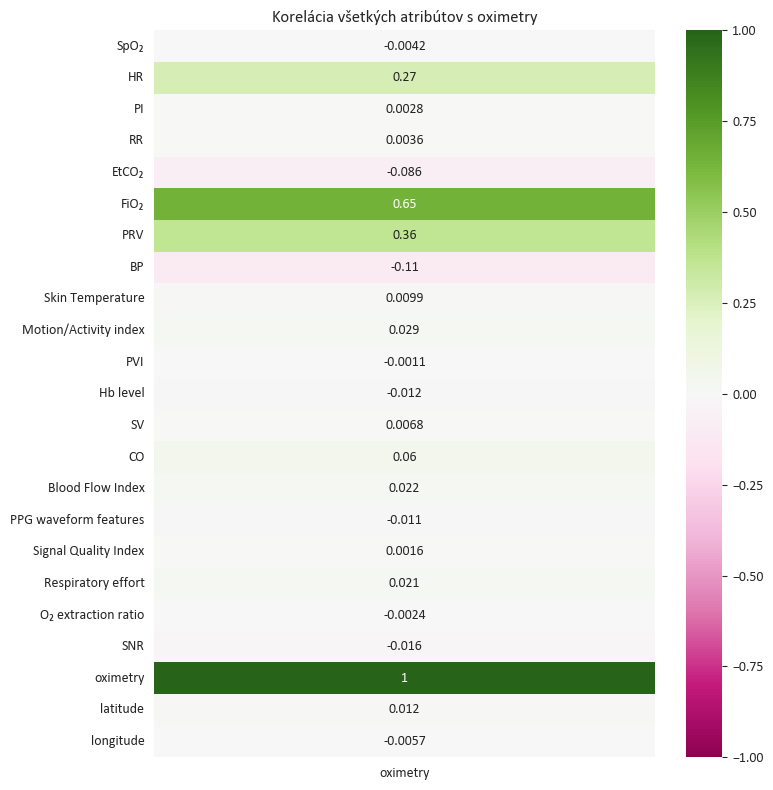

In [371]:
plt.figure(figsize=(8, 8))
sns.heatmap(
    corr_oxi[['oximetry']], # Len stĺpec targetu
    annot=True,
    cmap="PiYG",
    center=0,
    vmin=-1, vmax=1
)
plt.title("Korelácia všetkých atribútov s oximetry")
plt.tight_layout()
plt.show()

In [372]:
#Kolerácia je založená na tom, že čím bližšie je výsledok k 0, tým menší vzťah (vplyv) má k target hodnote, v tomto prípade "Oximetry". Naopak, čím bližšie je hodnota k 1/-1, tak tým silnejší je daný pozitívny/negatívny vzťah.

In [373]:
corr_with_target = df_observation.corr()['oximetry'].drop('oximetry').abs().sort_values(ascending=False)
print(corr_with_target) #Aby sme videli presnejšie hodnoty

FiO₂                     0.647962
PRV                      0.363694
HR                       0.271989
BP                       0.107735
EtCO₂                    0.085933
CO                       0.060462
Motion/Activity index    0.028655
Blood Flow Index         0.021551
Respiratory effort       0.021333
SNR                      0.016054
Hb level                 0.011953
latitude                 0.011599
PPG waveform features    0.010841
Skin Temperature         0.009898
SV                       0.006846
longitude                0.005732
SpO₂                     0.004202
RR                       0.003607
PI                       0.002846
O₂ extraction ratio      0.002415
Signal Quality Index     0.001638
PVI                      0.001063
Name: oximetry, dtype: float64


In [374]:
#Vyberieme TOP 10 Atribútov
key_attributes = corr_with_target.head(10).index.tolist() 
key_attributes

['FiO₂',
 'PRV',
 'HR',
 'BP',
 'EtCO₂',
 'CO',
 'Motion/Activity index',
 'Blood Flow Index',
 'Respiratory effort',
 'SNR']

In [375]:
##Charakterizacia vybranych TOP 10 atributov

In [376]:
#popis každého atribútu
attribute_info = {
    'FiO₂': {
        'názov': 'Fraction of Inspired Oxygen',
        'popis': 'Frakcia (%) kyslíka vo vdychovanom vzduchu',
        'význam': 'Určuje, koľko kyslíka je k dispozícii pre saturáciu krvi',
        'normálne hodnoty': '21% (okolité prostredie) až 100% (pri kyslíkovej terapii)'
    },
    'PRV': {
        'názov': 'Pulse Rate Variability',
        'popis': 'Variabilita pulzovej frekvencie',
        'význam': 'Indikuje aktivitu autonómneho nervového systému a srdcovú reguláciu',
        'normálne hodnoty': 'Vyššia variabilita = lepší zdravotný stav'
    },
    'HR': {
        'názov': 'Heart Rate',
        'popis': 'Srdcová frekvencia (počet úderov za minútu)',
        'význam': 'Základný kardiovaskulárny parameter, ovplyvňuje okysličenie tkanív',
        'normálne hodnoty': '60-100 úderov/min (dospelí v pokoji)'
    },
    'BP': {
        'názov': 'Blood Pressure',
        'popis': 'Krvný tlak (systolický/diastolický)',
        'význam': 'Ovplyvňuje perfúziu tkanív a distribúciu okysličenej krvi',
        'normálne hodnoty': '120/80 mmHg (optimálny)'
    },
    'EtCO₂': {
        'názov': 'End-tidal CO₂',
        'popis': 'Koncentrácia CO₂ na konci výdychu',
        'význam': 'Indikuje účinnosť ventilácie a výmeny plynov v pľúcach',
        'normálne hodnoty': '35-45 mmHg'
    },
    'CO': {
        'názov': 'Cardiac Output',
        'popis': 'Srdcový výdaj (objem krvi vypumpovaný za minútu)',
        'význam': 'Efektivita distribúcie okysličenej krvi do celého tela',
        'normálne hodnoty': '4-8 L/min (dospelí)'
    },
    'Motion/Activity index': {
        'názov': 'Index pohybu/aktivity',
        'popis': 'Miera fyzickej aktivity pacienta',
        'význam': 'Pohyb ovplyvňuje spotrebu kyslíka a kvalitu signálu senzorov',
        'normálne hodnoty': '0 = bez pohybu, vyššie hodnoty = aktívny pohyb'
    },
    'Blood Flow Index': {
        'názov': 'Index prietoku krvi',
        'popis': 'Relatívna miera periférneho prietoku krvi',
        'význam': 'Indikuje kvalitu perfúzie a schopnosť dodať kyslík do tkanív',
        'normálne hodnoty': 'Vyššie hodnoty = lepšia perfúzia'
    },
    'Respiratory effort': {
        'názov': 'Dychové úsilie',
        'popis': 'Námaha vynaložená na dýchanie',
        'význam': 'Vysoké úsilie môže indikovať respiračný problém',
        'normálne hodnoty': 'Nižšie hodnoty = normálne dýchanie'
    },
    'SNR': {
        'názov': 'Signal-to-Noise Ratio',
        'popis': 'Pomer signálu k šumu',
        'význam': 'Technická kvalita merania, ovplyvňuje spoľahlivosť všetkých parametrov',
        'normálne hodnoty': 'Vyššie hodnoty = kvalitnejší signál'
    }
}

In [377]:
for attr in key_attributes:
    info = attribute_info[attr]
    corr = df_observation.corr()['oximetry'][attr]
    print(f"{attr}")
    print(f"")
    print(f"Názov: {info['názov']}")
    print(f"Popis: {info['popis']}")
    print(f"Klinický význam: {info['význam']}")
    print(f"Referenčné hodnoty: {info['normálne hodnoty']}")
    print(f"Korelácia s oximetry: {corr:.5f}")
    print()

FiO₂

Názov: Fraction of Inspired Oxygen
Popis: Frakcia (%) kyslíka vo vdychovanom vzduchu
Klinický význam: Určuje, koľko kyslíka je k dispozícii pre saturáciu krvi
Referenčné hodnoty: 21% (okolité prostredie) až 100% (pri kyslíkovej terapii)
Korelácia s oximetry: 0.64796

PRV

Názov: Pulse Rate Variability
Popis: Variabilita pulzovej frekvencie
Klinický význam: Indikuje aktivitu autonómneho nervového systému a srdcovú reguláciu
Referenčné hodnoty: Vyššia variabilita = lepší zdravotný stav
Korelácia s oximetry: 0.36369

HR

Názov: Heart Rate
Popis: Srdcová frekvencia (počet úderov za minútu)
Klinický význam: Základný kardiovaskulárny parameter, ovplyvňuje okysličenie tkanív
Referenčné hodnoty: 60-100 úderov/min (dospelí v pokoji)
Korelácia s oximetry: 0.27199

BP

Názov: Blood Pressure
Popis: Krvný tlak (systolický/diastolický)
Klinický význam: Ovplyvňuje perfúziu tkanív a distribúciu okysličenej krvi
Referenčné hodnoty: 120/80 mmHg (optimálny)
Korelácia s oximetry: -0.10774

EtCO₂

Ná

In [378]:
#ŠTATISTICKÉ CHARAKTERISTIKY VYBRANÝCH ATRIBÚTOV

In [379]:
# Rozšírená štatistika
distribution_stats = df_observation[key_attributes].describe().T
distribution_stats['skewness'] = df_observation[key_attributes].skew()
distribution_stats['null'] = df_observation[key_attributes].isnull().sum()

In [380]:
print(distribution_stats.round(3))

                         count     mean     std     min      25%      50%  \
FiO₂                   12150.0   58.681  13.630  21.000   48.226   59.893   
PRV                    12150.0  119.917  28.754  20.000   96.216  125.208   
HR                     12150.0   80.121   5.790  60.000   75.731   80.151   
BP                     12150.0  103.322   3.585  90.000  100.918  103.379   
EtCO₂                  12150.0   39.764   1.771  35.000   38.414   39.409   
CO                     12150.0    4.018   0.083   4.000    4.000    4.002   
Motion/Activity index  12150.0   10.667   1.557   4.357    9.654   10.654   
Blood Flow Index       12150.0   52.095  12.016   0.000   43.947   52.210   
Respiratory effort     12150.0   47.660  12.616   0.000   39.345   47.581   
SNR                    12150.0   29.987   5.761  20.000   24.982   30.072   

                           75%     max  skewness  null  
FiO₂                    69.218  100.00    -0.141     0  
PRV                    141.496  200.00

In [381]:
##Distribúcie pre jednotlivé atribúty

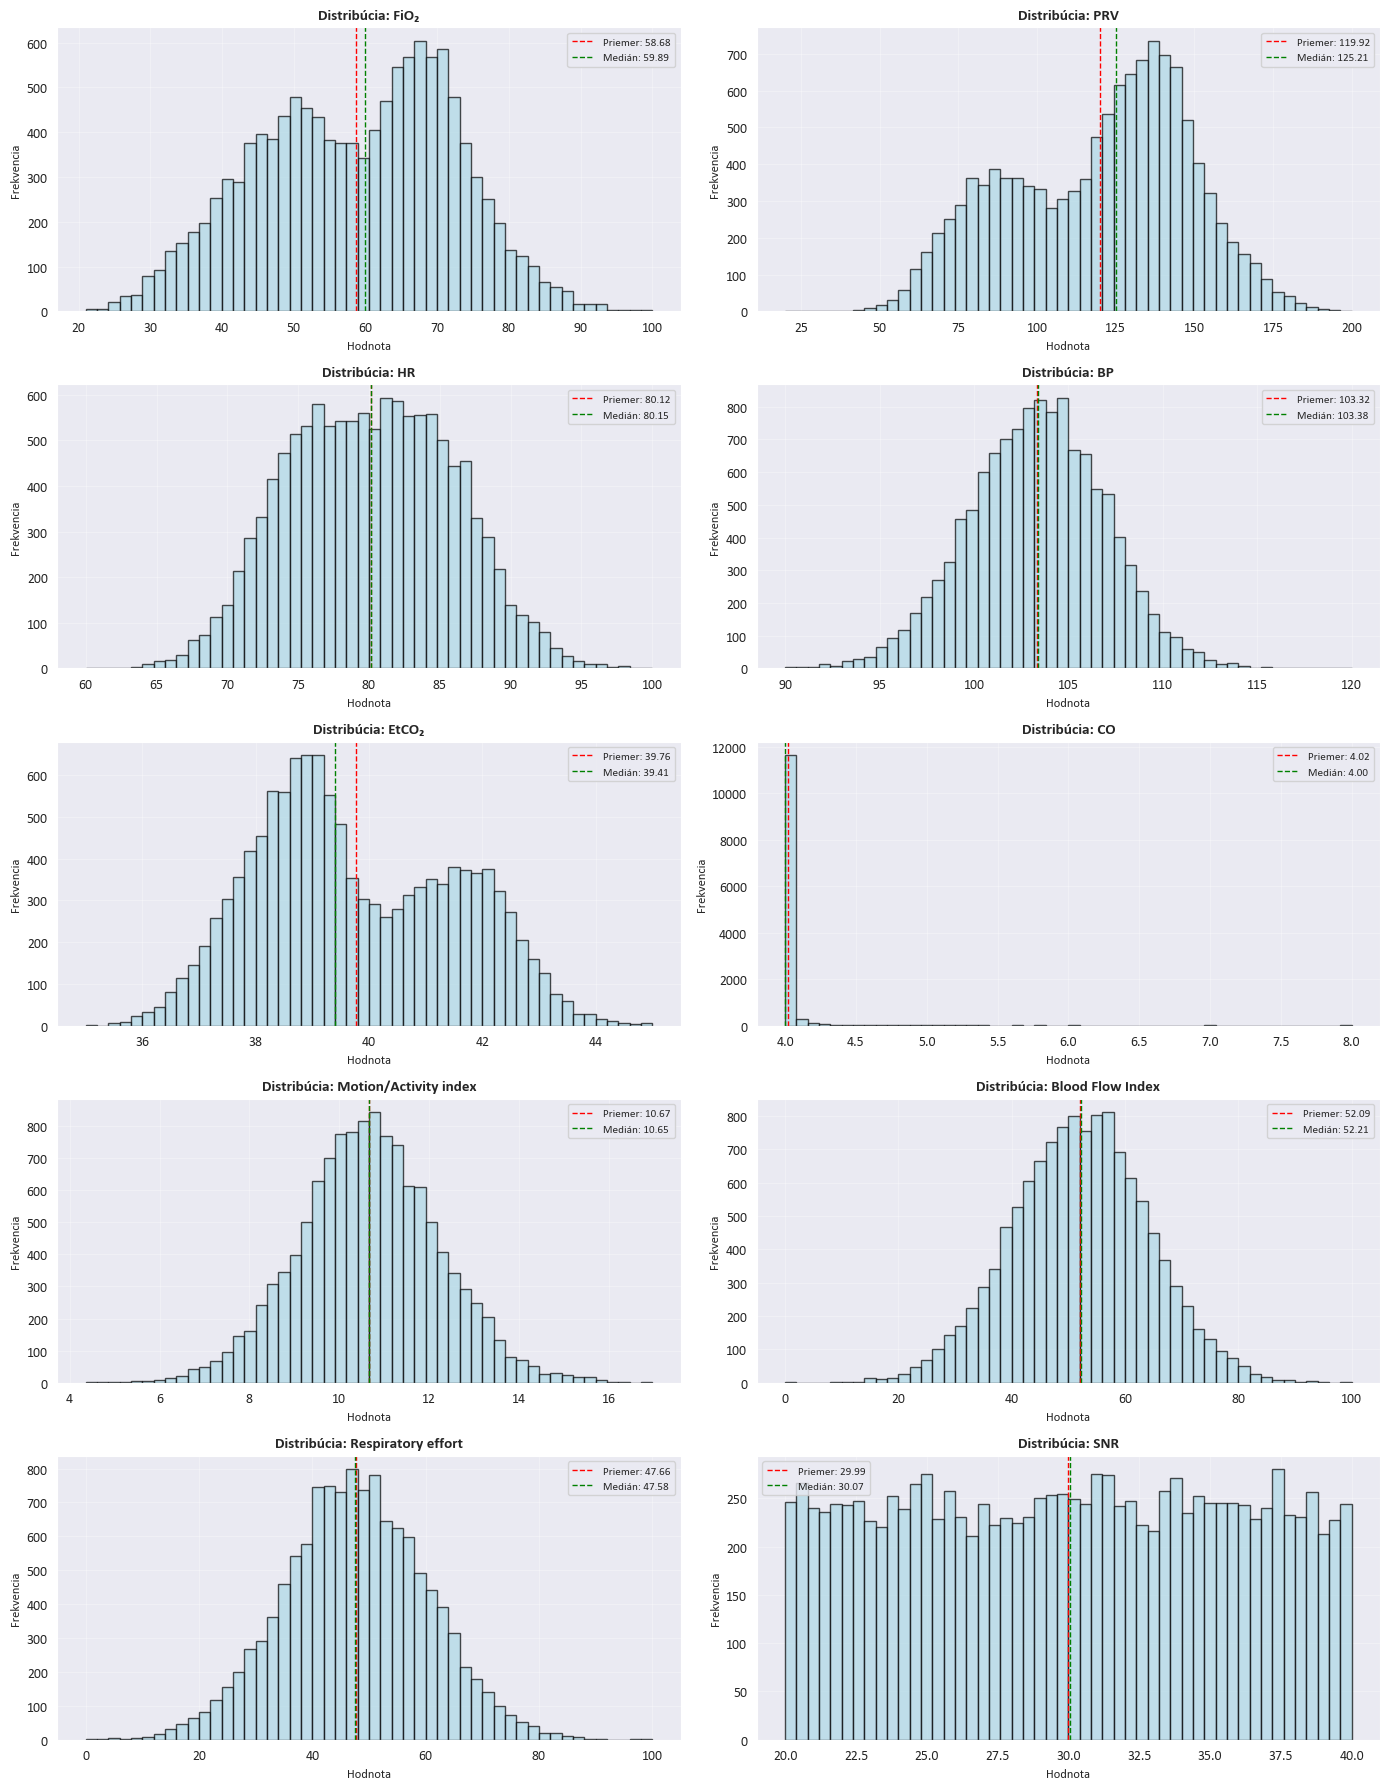

In [382]:
# Histogramy
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for idx, col in enumerate(key_attributes):
    axes[idx].hist(df_observation[col].dropna(), bins=50, edgecolor='black', 
                   alpha=0.7, color='lightblue')
    axes[idx].set_title(f'Distribúcia: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Hodnota', fontsize=9)
    axes[idx].set_ylabel('Frekvencia', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    
    #základné štatistiky
    mean_val = df_observation[col].mean()
    median_val = df_observation[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Priemer: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Medián: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [383]:
##Box Plots

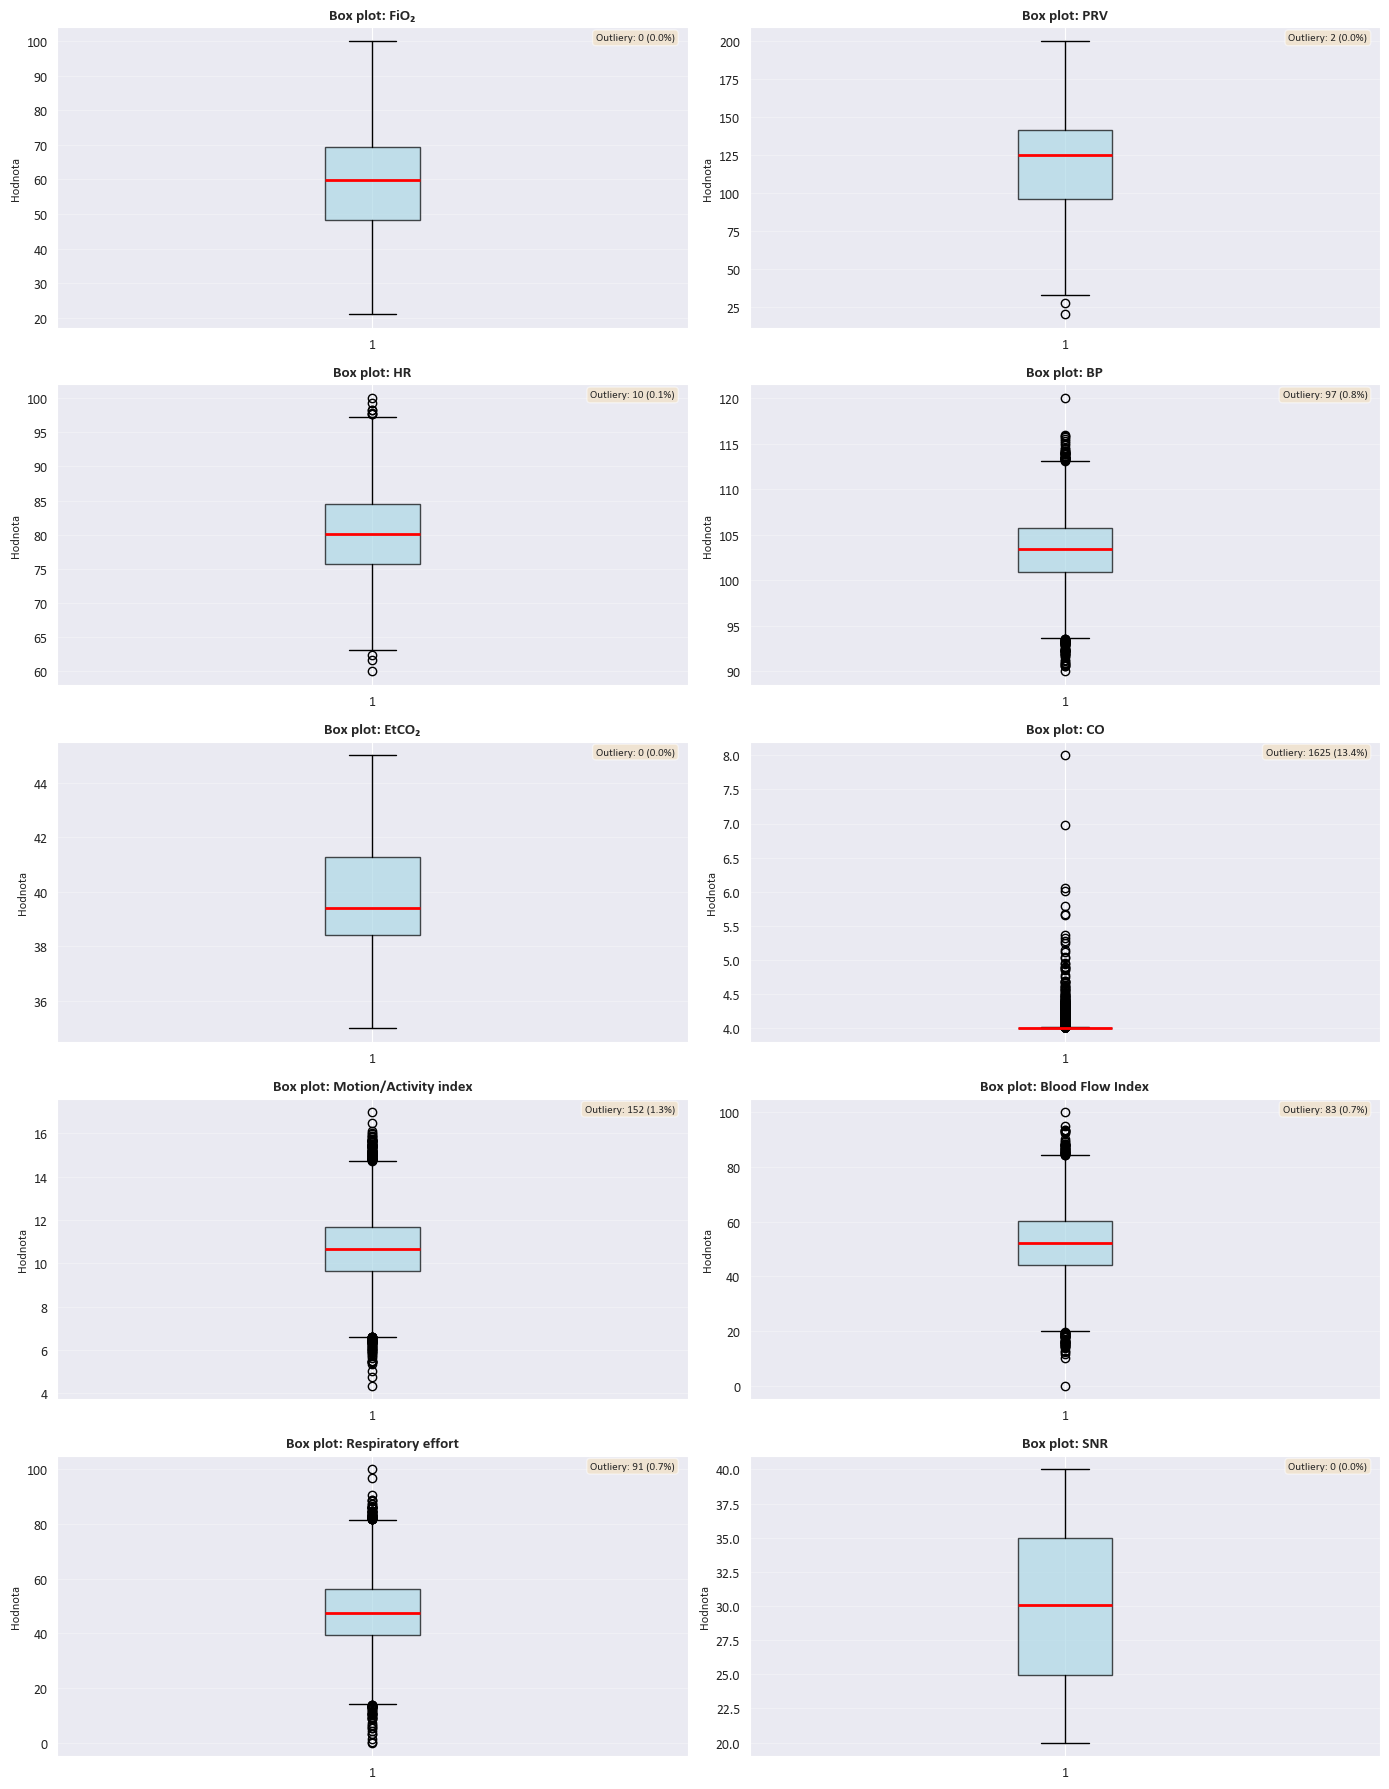

In [384]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for idx, col in enumerate(key_attributes):
    data = df_observation[col].dropna()
    bp = axes[idx].boxplot(data, vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightblue', alpha=0.7),
                            medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'Box plot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Hodnota', fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Pridáme informáciu o outlieroch
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    axes[idx].text(0.98, 0.98, f'Outliery: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)',
                   transform=axes[idx].transAxes, fontsize=8,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [385]:
##Informácie o box plotoch:
#1. Spodná čiara boxu: 25. percentil (Q1) - 25% hodnôt je pod touto úrovňou
#2. Červená čiara v boxe: Medián (50. percentil) - stred dát
#3. Horná čiara boxu: 75. percentil (Q3) - 75% hodnôt je pod touto úrovňou
#4. Kruhy mimo "whiskers": Outliery - extrémne hodnoty, ktoré sa výrazne odchyľujú od zvyšku dát

In [386]:
##Podľa tohto môžeme povedať nasledovné:
#A) FiO₂, PRV, HR, BP, EtCO₂: Pomerne symetrické rozloženie, málo outlierov - stabilné merania
#B) CO (Cardiac Output): Veľmi veľa outlierov (13.4%) - extrémne hodnoty naznačujú buď merací šum alebo pacientov s abnormálnymi kardiovaskulárnymi stavmi
#C) Motion/Activity index, Respiratory effort: Veľa outlierov (1.4%, 0.7%) - normálne, keďže pacienti majú rôznu úroveň aktivity
#D) Blood Flow Index, SNR: Málo outlierov - relatívne konzistentné merania

#Výsledok boxplotov odhalili kvalitu meraní a variabilitu medzi pacientmi, kde vysoký počet outlierov môže naznačovať potrebu filtrácie dát a pod.

In [387]:
##Zhrnutie poznatkov doterajšej analýzy

In [388]:
for attr in key_attributes:
    data = df_observation[attr].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    
    print(f"{attr}:")
    
    #skewness
    if abs(skew) < 0.5:
        skew_interp = "približne symetrická"
    elif skew > 0:
        skew_interp = "pravostranná (dlhý pravý chvost)"
    else:
        skew_interp = "ľavostranná (dlhý ľavý chvost)"
    
    #špicatosť
    if abs(kurt) < 0.5:
        kurt_interp = "normálne rozloženie"
    elif kurt > 0:
        kurt_interp = "špicaté rozloženie (viac extrémnych hodnôt)"
    else:
        kurt_interp = "ploché rozloženie (menej extrémnych hodnôt)"
    
    print(f"  - Distribúcia je {skew_interp}")
    print(f"  - Špicatosť: {kurt_interp}")
    print(f"  - Rozsah: {data.min():.2f} až {data.max():.2f}")
    print(f"  - Variačný koeficient: {(data.std()/data.mean()*100):.1f}%")
    print()

FiO₂:
  - Distribúcia je približne symetrická
  - Špicatosť: ploché rozloženie (menej extrémnych hodnôt)
  - Rozsah: 21.00 až 100.00
  - Variačný koeficient: 23.2%

PRV:
  - Distribúcia je približne symetrická
  - Špicatosť: ploché rozloženie (menej extrémnych hodnôt)
  - Rozsah: 20.00 až 200.00
  - Variačný koeficient: 24.0%

HR:
  - Distribúcia je približne symetrická
  - Špicatosť: ploché rozloženie (menej extrémnych hodnôt)
  - Rozsah: 60.00 až 100.00
  - Variačný koeficient: 7.2%

BP:
  - Distribúcia je približne symetrická
  - Špicatosť: normálne rozloženie
  - Rozsah: 90.00 až 120.00
  - Variačný koeficient: 3.5%

EtCO₂:
  - Distribúcia je približne symetrická
  - Špicatosť: ploché rozloženie (menej extrémnych hodnôt)
  - Rozsah: 35.00 až 45.00
  - Variačný koeficient: 4.5%

CO:
  - Distribúcia je pravostranná (dlhý pravý chvost)
  - Špicatosť: špicaté rozloženie (viac extrémnych hodnôt)
  - Rozsah: 4.00 až 8.00
  - Variačný koeficient: 2.1%

Motion/Activity index:
  - Distribúc

In [389]:
##C)Párová analýza medzi atribútmi

                        FiO₂    PRV     HR     BP  EtCO₂     CO  \
FiO₂                   1.000  0.327  0.182 -0.096 -0.055  0.085   
PRV                    0.327  1.000 -0.114  0.004 -0.462 -0.012   
HR                     0.182 -0.114  1.000  0.061  0.369  0.394   
BP                    -0.096  0.004  0.061  1.000  0.078  0.045   
EtCO₂                 -0.055 -0.462  0.369  0.078  1.000  0.167   
CO                     0.085 -0.012  0.394  0.045  0.167  1.000   
Motion/Activity index  0.120  0.034  0.092 -0.042  0.014  0.031   
Blood Flow Index       0.017 -0.009  0.007 -0.004  0.007  0.007   
Respiratory effort     0.022  0.026 -0.003 -0.009  0.000 -0.005   
SNR                   -0.017 -0.004  0.002 -0.002  0.003  0.005   

                       Motion/Activity index  Blood Flow Index  \
FiO₂                                   0.120             0.017   
PRV                                    0.034            -0.009   
HR                                     0.092             0.007  

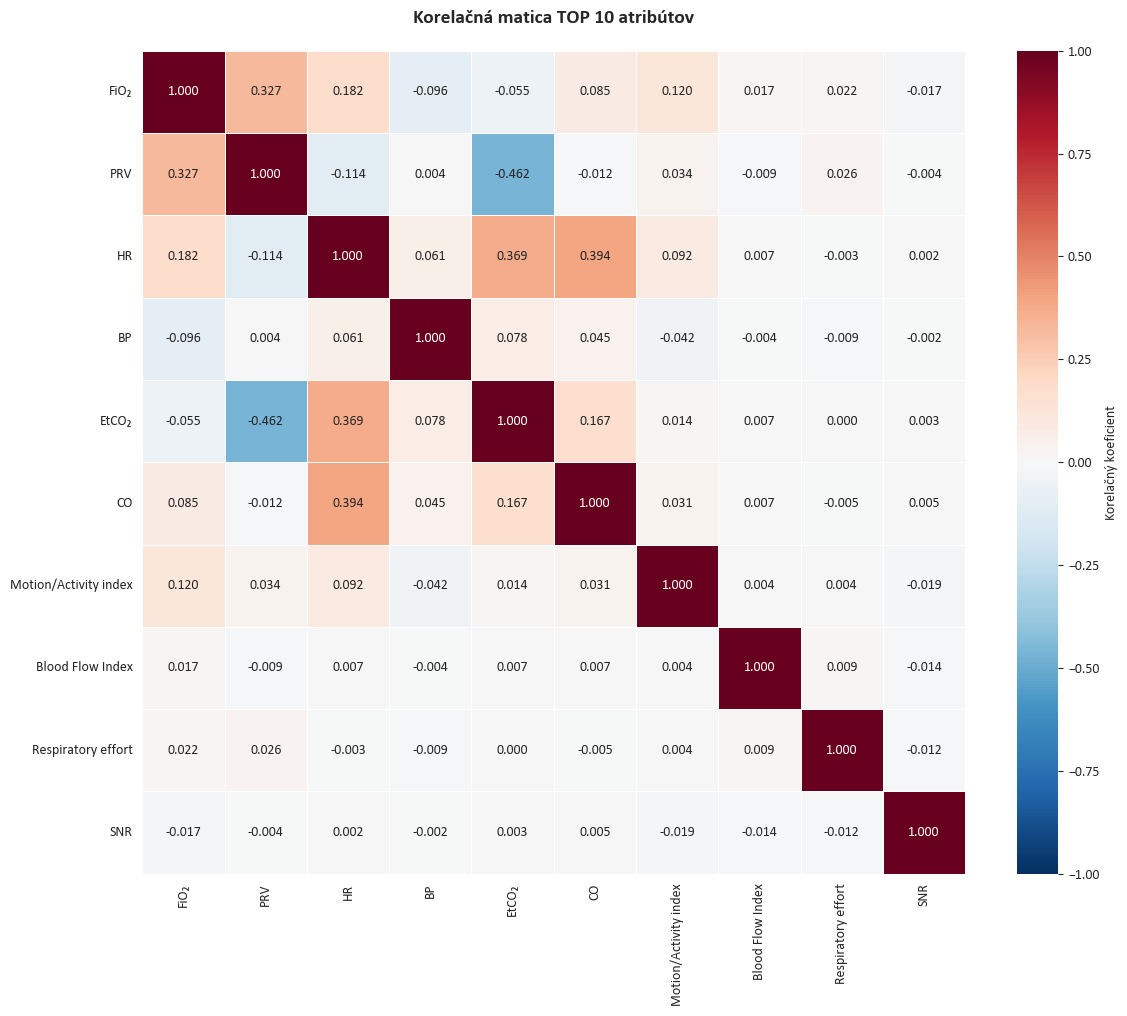

In [390]:
correlation_matrix = df_observation[key_attributes].corr()
print(correlation_matrix.round(3))

# Vizualizácia korelačnej matice
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.3f',
    cmap='RdBu_r', 
    center=0,
    vmin=-1, 
    vmax=1,
    square=True,
    cbar_kws={'label': 'Korelačný koeficient'},
    linewidths=0.5
)
plt.title('Korelačná matica TOP 10 atribútov', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [391]:
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        attr1 = correlation_matrix.columns[i]
        attr2 = correlation_matrix.columns[j]
        corr_val = correlation_matrix.iloc[i, j]
        
        corr_pairs.append({
            'Atribút 1': attr1,
            'Atribút 2': attr2,
            'Korelácia': corr_val,
            'Abs. korelácia': abs(corr_val)
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df_sorted = corr_df.sort_values('Abs. korelácia', ascending=False)

print("TOP 15 NAJSILNEJŠÍCH KORELÁCIÍ MEDZI ATRIBÚTMI\n")
print(corr_df_sorted.head(15)[['Atribút 1', 'Atribút 2', 'Korelácia']].to_string(index=False))


TOP 15 NAJSILNEJŠÍCH KORELÁCIÍ MEDZI ATRIBÚTMI

Atribút 1             Atribút 2  Korelácia
      PRV                 EtCO₂  -0.462149
       HR                    CO   0.394155
       HR                 EtCO₂   0.368850
     FiO₂                   PRV   0.327156
     FiO₂                    HR   0.181625
    EtCO₂                    CO   0.167269
     FiO₂ Motion/Activity index   0.120203
      PRV                    HR  -0.114461
     FiO₂                    BP  -0.096030
       HR Motion/Activity index   0.092066
     FiO₂                    CO   0.084733
       BP                 EtCO₂   0.077569
       HR                    BP   0.061428
     FiO₂                 EtCO₂  -0.054734
       BP                    CO   0.045099


In [392]:
top_pairs = corr_df_sorted.head(10)
for idx, row in top_pairs.iterrows():
    attr1, attr2, corr = row['Atribút 1'], row['Atribút 2'], row['Korelácia']
    
    if corr > 0:
        vztah = "pozitívna korelácia"
        vysvetlenie = "Ako rastie jeden atribút, rastie aj druhý"
    else:
        vztah = "negatívna korelácia"
        vysvetlenie = "Ako rastie jeden atribút, druhý klesá"
    
    if abs(corr) > 0.7:
        sila = "veľmi silný"
    elif abs(corr) > 0.5:
        sila = "stredne silný"
    else:
        sila = "slabý"
    
    print(f"{attr1} ↔ {attr2}")
    print(f"  Korelácia: {corr:.4f} ({sila} {vztah})")
    print(f"  {vysvetlenie}")
    print()

PRV ↔ EtCO₂
  Korelácia: -0.4621 (slabý negatívna korelácia)
  Ako rastie jeden atribút, druhý klesá

HR ↔ CO
  Korelácia: 0.3942 (slabý pozitívna korelácia)
  Ako rastie jeden atribút, rastie aj druhý

HR ↔ EtCO₂
  Korelácia: 0.3689 (slabý pozitívna korelácia)
  Ako rastie jeden atribút, rastie aj druhý

FiO₂ ↔ PRV
  Korelácia: 0.3272 (slabý pozitívna korelácia)
  Ako rastie jeden atribút, rastie aj druhý

FiO₂ ↔ HR
  Korelácia: 0.1816 (slabý pozitívna korelácia)
  Ako rastie jeden atribút, rastie aj druhý

EtCO₂ ↔ CO
  Korelácia: 0.1673 (slabý pozitívna korelácia)
  Ako rastie jeden atribút, rastie aj druhý

FiO₂ ↔ Motion/Activity index
  Korelácia: 0.1202 (slabý pozitívna korelácia)
  Ako rastie jeden atribút, rastie aj druhý

PRV ↔ HR
  Korelácia: -0.1145 (slabý negatívna korelácia)
  Ako rastie jeden atribút, druhý klesá

FiO₂ ↔ BP
  Korelácia: -0.0960 (slabý negatívna korelácia)
  Ako rastie jeden atribút, druhý klesá

HR ↔ Motion/Activity index
  Korelácia: 0.0921 (slabý pozitív

In [393]:
##D)Párová analýza s Oximetry

In [394]:
# Pre každý atribút analyzujeme vzťah s oximetry
for attr in key_attributes:
    corr = df_observation[[attr, 'oximetry']].corr().iloc[0, 1]
    
    print(f"PÁR: {attr} ↔ oximetry")
    print(f"{'-'*20}")
    print(f"Korelačný koeficient: {corr:.4f}\n")
    
    # Interpretácia sily a smeru
    if abs(corr) > 0.7:
        sila = "veľmi silný"
    elif abs(corr) > 0.5:
        sila = "stredne silný"
    elif abs(corr) > 0.3:
        sila = "slabý až stredný"
    else:
        sila = "slabý"
    
    if corr > 0:
        smer = "pozitívny"
        vysvetlenie = f"Keď {attr} rastie, oximetry má tendenciu tiež rásť"
    else:
        smer = "negatívny"
        vysvetlenie = f"Keď {attr} rastie, oximetry má tendenciu klesať"
    
    print(f"Sila vzťahu: {sila}")
    print(f"Smer vzťahu: {smer}")
    print(f"Interpretácia: {vysvetlenie}\n")
    
    # Štatistický test významnosti korelácie
    n = len(df_observation[[attr, 'oximetry']].dropna())
    if n > 2:
        t_stat = corr * np.sqrt((n-2)/(1-corr**2))
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
        
        if p_value < 0.001:
            print(f"Štatistická významnosť: *** (p < 0.001) - vysoko signifikantný vzťah")
        elif p_value < 0.01:
            print(f"Štatistická významnosť: ** (p < 0.01) - signifikantný vzťah")
        elif p_value < 0.05:
            print(f"Štatistická významnosť: * (p < 0.05) - signifikantný vzťah")
        else:
            print(f"Štatistická významnosť: ns (p = {p_value:.4f}) - nesignifikantný vzťah")
    
    print()

PÁR: FiO₂ ↔ oximetry
--------------------
Korelačný koeficient: 0.6480

Sila vzťahu: stredne silný
Smer vzťahu: pozitívny
Interpretácia: Keď FiO₂ rastie, oximetry má tendenciu tiež rásť

Štatistická významnosť: *** (p < 0.001) - vysoko signifikantný vzťah

PÁR: PRV ↔ oximetry
--------------------
Korelačný koeficient: 0.3637

Sila vzťahu: slabý až stredný
Smer vzťahu: pozitívny
Interpretácia: Keď PRV rastie, oximetry má tendenciu tiež rásť

Štatistická významnosť: *** (p < 0.001) - vysoko signifikantný vzťah

PÁR: HR ↔ oximetry
--------------------
Korelačný koeficient: 0.2720

Sila vzťahu: slabý
Smer vzťahu: pozitívny
Interpretácia: Keď HR rastie, oximetry má tendenciu tiež rásť

Štatistická významnosť: *** (p < 0.001) - vysoko signifikantný vzťah

PÁR: BP ↔ oximetry
--------------------
Korelačný koeficient: -0.1077

Sila vzťahu: slabý
Smer vzťahu: negatívny
Interpretácia: Keď BP rastie, oximetry má tendenciu klesať

Štatistická významnosť: *** (p < 0.001) - vysoko signifikantný vzťa

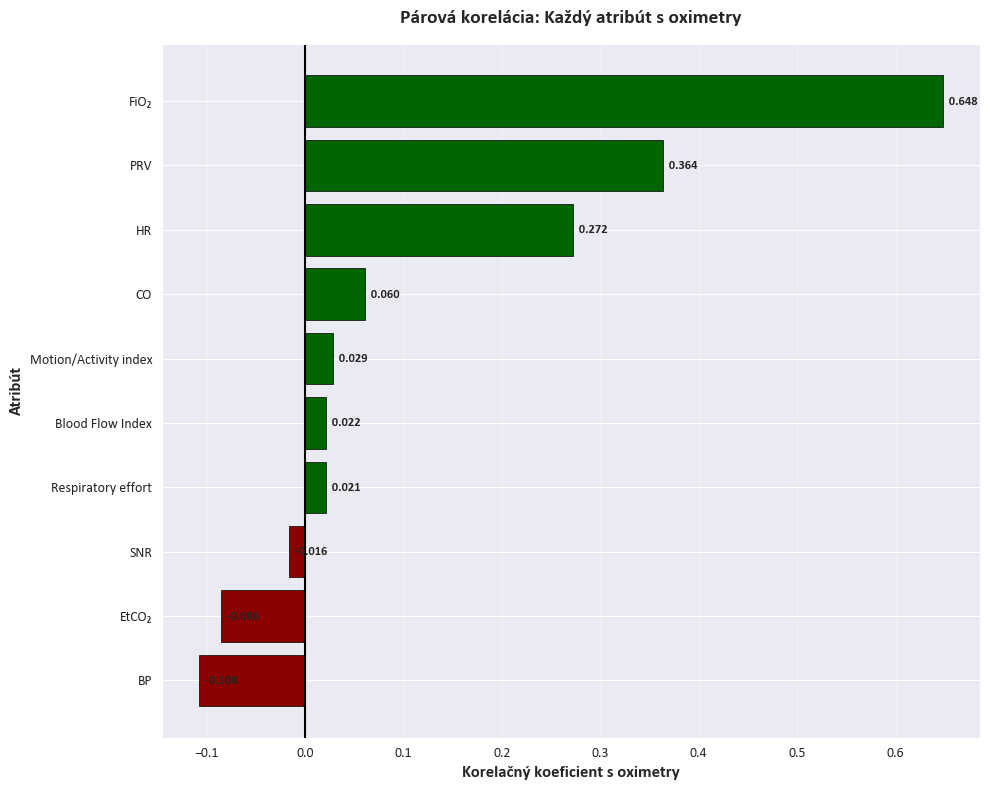

In [395]:
correlations = []
for attr in key_attributes:
    corr = df_observation[[attr, 'oximetry']].corr().iloc[0, 1]
    correlations.append({'Atribút': attr, 'Korelácia': corr})

corr_df = pd.DataFrame(correlations).sort_values('Korelácia', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['darkgreen' if x > 0 else 'darkred' for x in corr_df['Korelácia']]
plt.barh(corr_df['Atribút'], corr_df['Korelácia'], color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Korelačný koeficient s oximetry', fontsize=12, fontweight='bold')
plt.ylabel('Atribút', fontsize=12, fontweight='bold')
plt.title('Párová korelácia: Každý atribút s oximetry', fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(True, alpha=0.3, axis='x')

# Pridanie hodnôt na koniec každého stĺpca
for i, (idx, row) in enumerate(corr_df.iterrows()):
    plt.text(row['Korelácia'], i, f"  {row['Korelácia']:.3f}", 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [396]:
#Kontingenčné tabuľky pre kategorickú analýzu

In [397]:
print("\nKONTINGENČNÁ ANALÝZA: PRIEMER ATRIBÚTOV PRE oximetry = 0 vs 1")
print("-"*80)
comparison_data = []
for attr in key_attributes:
    mean_0 = df_observation[df_observation['oximetry'] == 0][attr].mean()
    mean_1 = df_observation[df_observation['oximetry'] == 1][attr].mean()
    diff = mean_1 - mean_0
    diff_percent = (diff / mean_0 * 100) if mean_0 != 0 else 0
    
    comparison_data.append({
        'Atribút': attr,
        'Priemer (ox=0)': mean_0,
        'Priemer (ox=1)': mean_1,
        'Rozdiel': diff,
        'Rozdiel (%)': diff_percent
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(3).to_string(index=False))


KONTINGENČNÁ ANALÝZA: PRIEMER ATRIBÚTOV PRE oximetry = 0 vs 1
--------------------------------------------------------------------------------
              Atribút  Priemer (ox=0)  Priemer (ox=1)  Rozdiel  Rozdiel (%)
                 FiO₂          47.972          65.964   17.993       37.507
                  PRV         107.236         128.540   21.304       19.866
                   HR          78.211          81.420    3.208        4.102
                   BP         103.791         103.004   -0.787       -0.758
                EtCO₂          39.948          39.638   -0.310       -0.776
                   CO           4.012           4.022    0.010        0.256
Motion/Activity index          10.613          10.704    0.091        0.857
     Blood Flow Index          51.781          52.308    0.528        1.019
   Respiratory effort          47.333          47.882    0.548        1.158
                  SNR          30.099          29.911   -0.188       -0.626


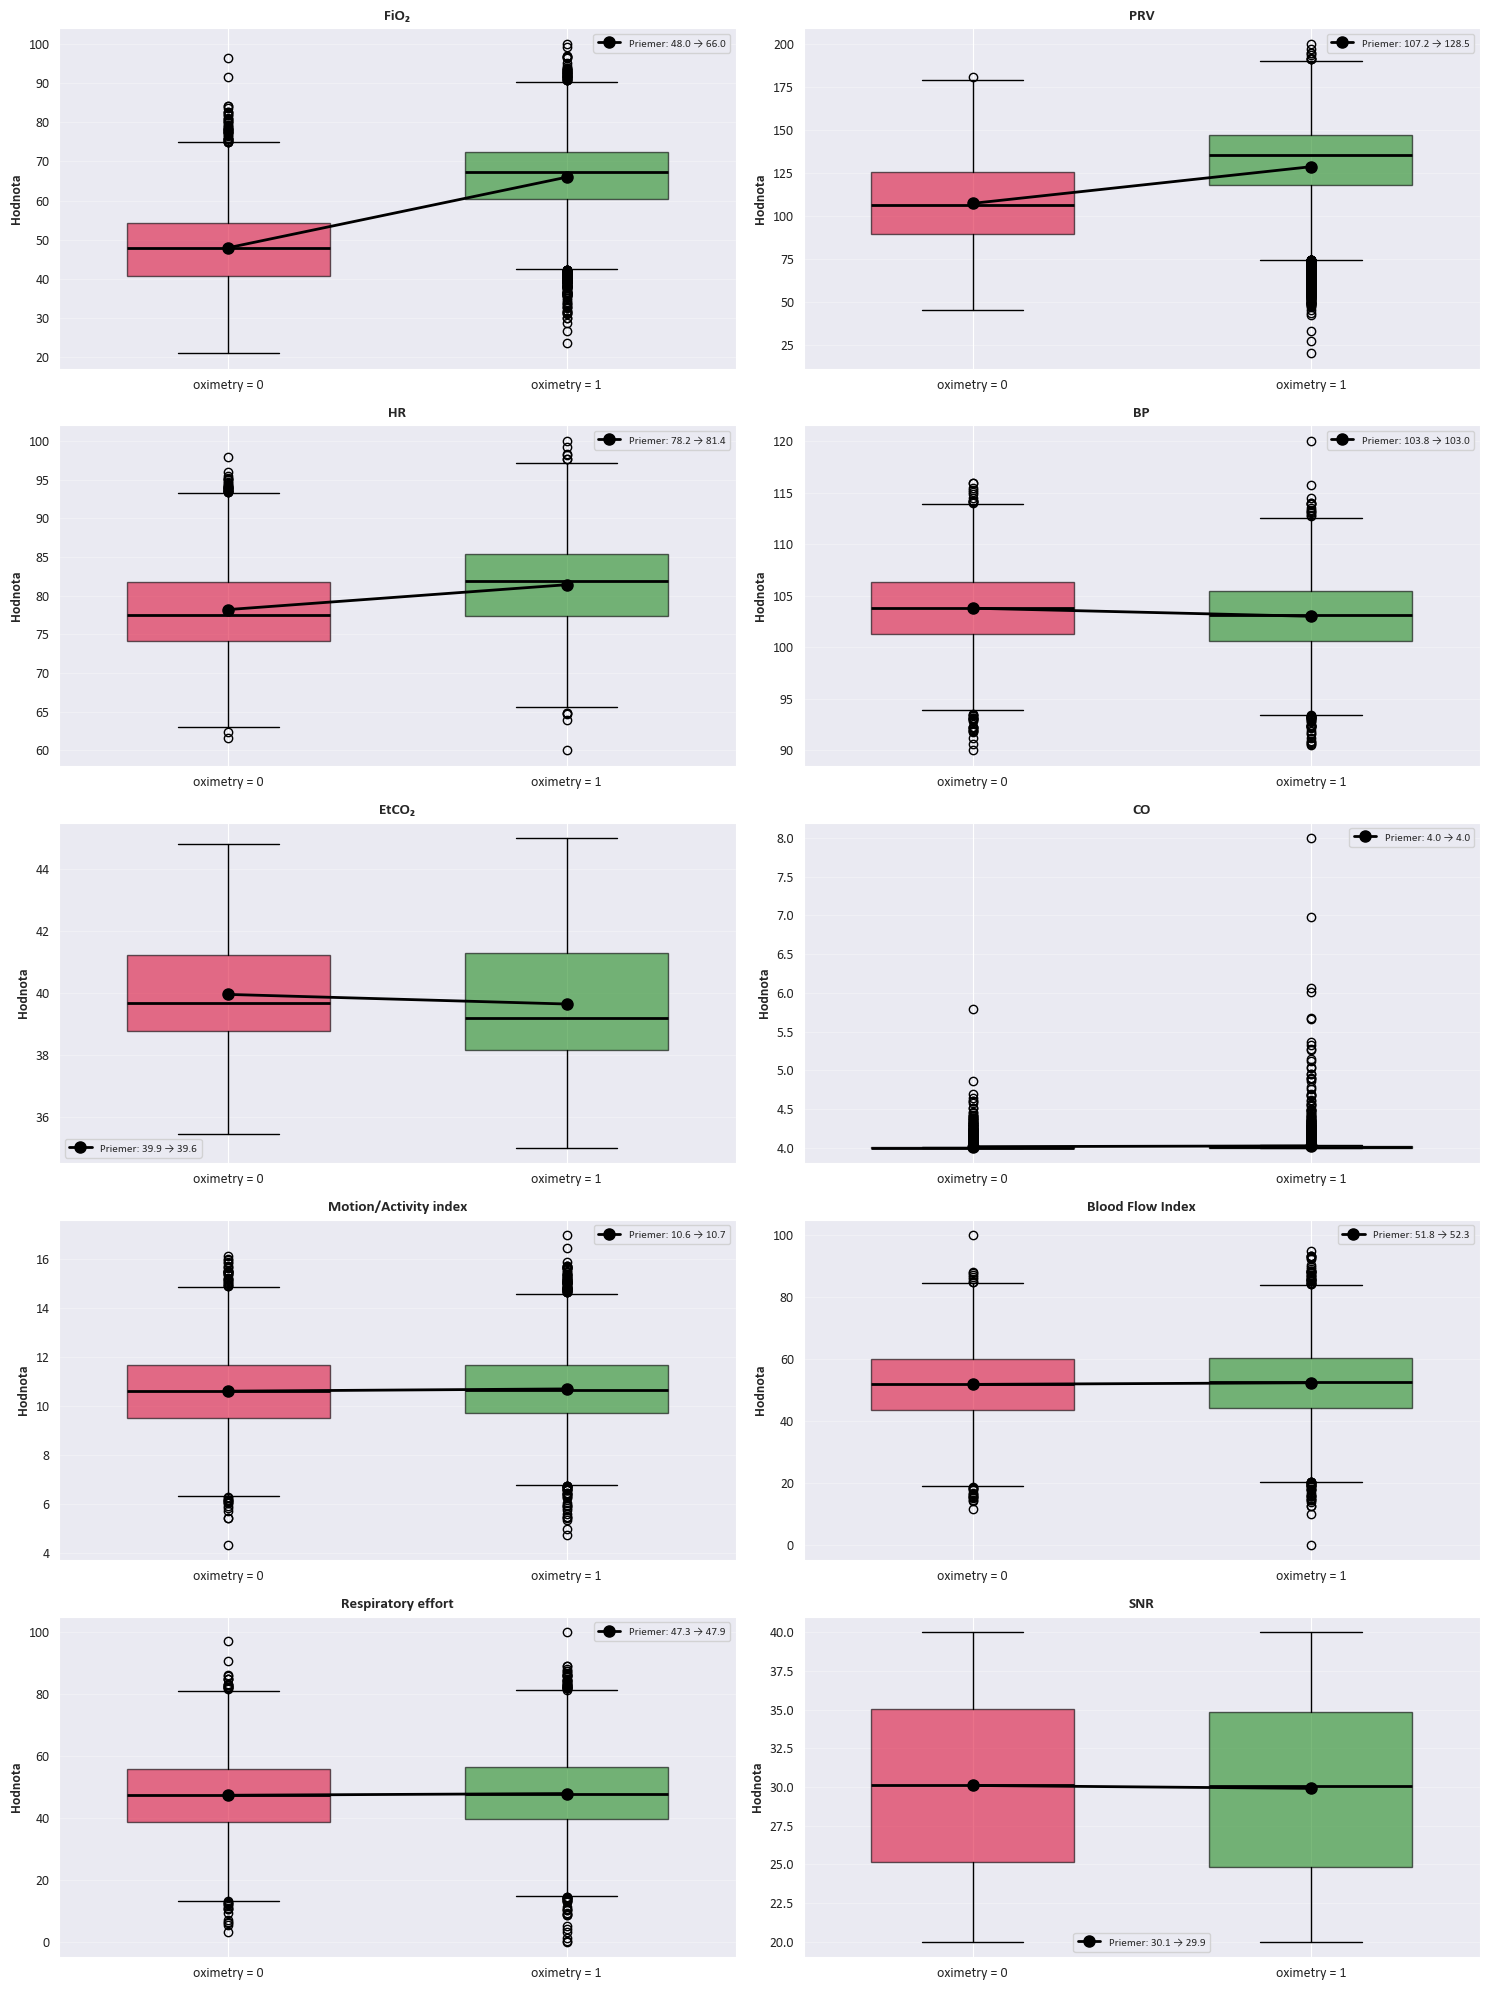

In [398]:
#Zobrazenie predchádzajúcich hodnôt v boxplotoch
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, attr in enumerate(key_attributes):
    data_0 = df_observation[df_observation['oximetry'] == 0][attr].dropna()
    data_1 = df_observation[df_observation['oximetry'] == 1][attr].dropna()
    
    bp = axes[idx].boxplot([data_0, data_1], 
                           tick_labels=['oximetry = 0', 'oximetry = 1'],
                           patch_artist=True,
                           widths=0.6)
    
    # Farebné rozlíšenie
    bp['boxes'][0].set_facecolor('crimson')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('forestgreen')
    bp['boxes'][1].set_alpha(0.6)
    
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    axes[idx].set_ylabel('Hodnota', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{attr}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Pridanie priemerov
    mean_0 = data_0.mean()
    mean_1 = data_1.mean()
    axes[idx].plot([1, 2], [mean_0, mean_1], 'ko-', linewidth=2, markersize=8, 
                   label=f'Priemer: {mean_0:.1f} → {mean_1:.1f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

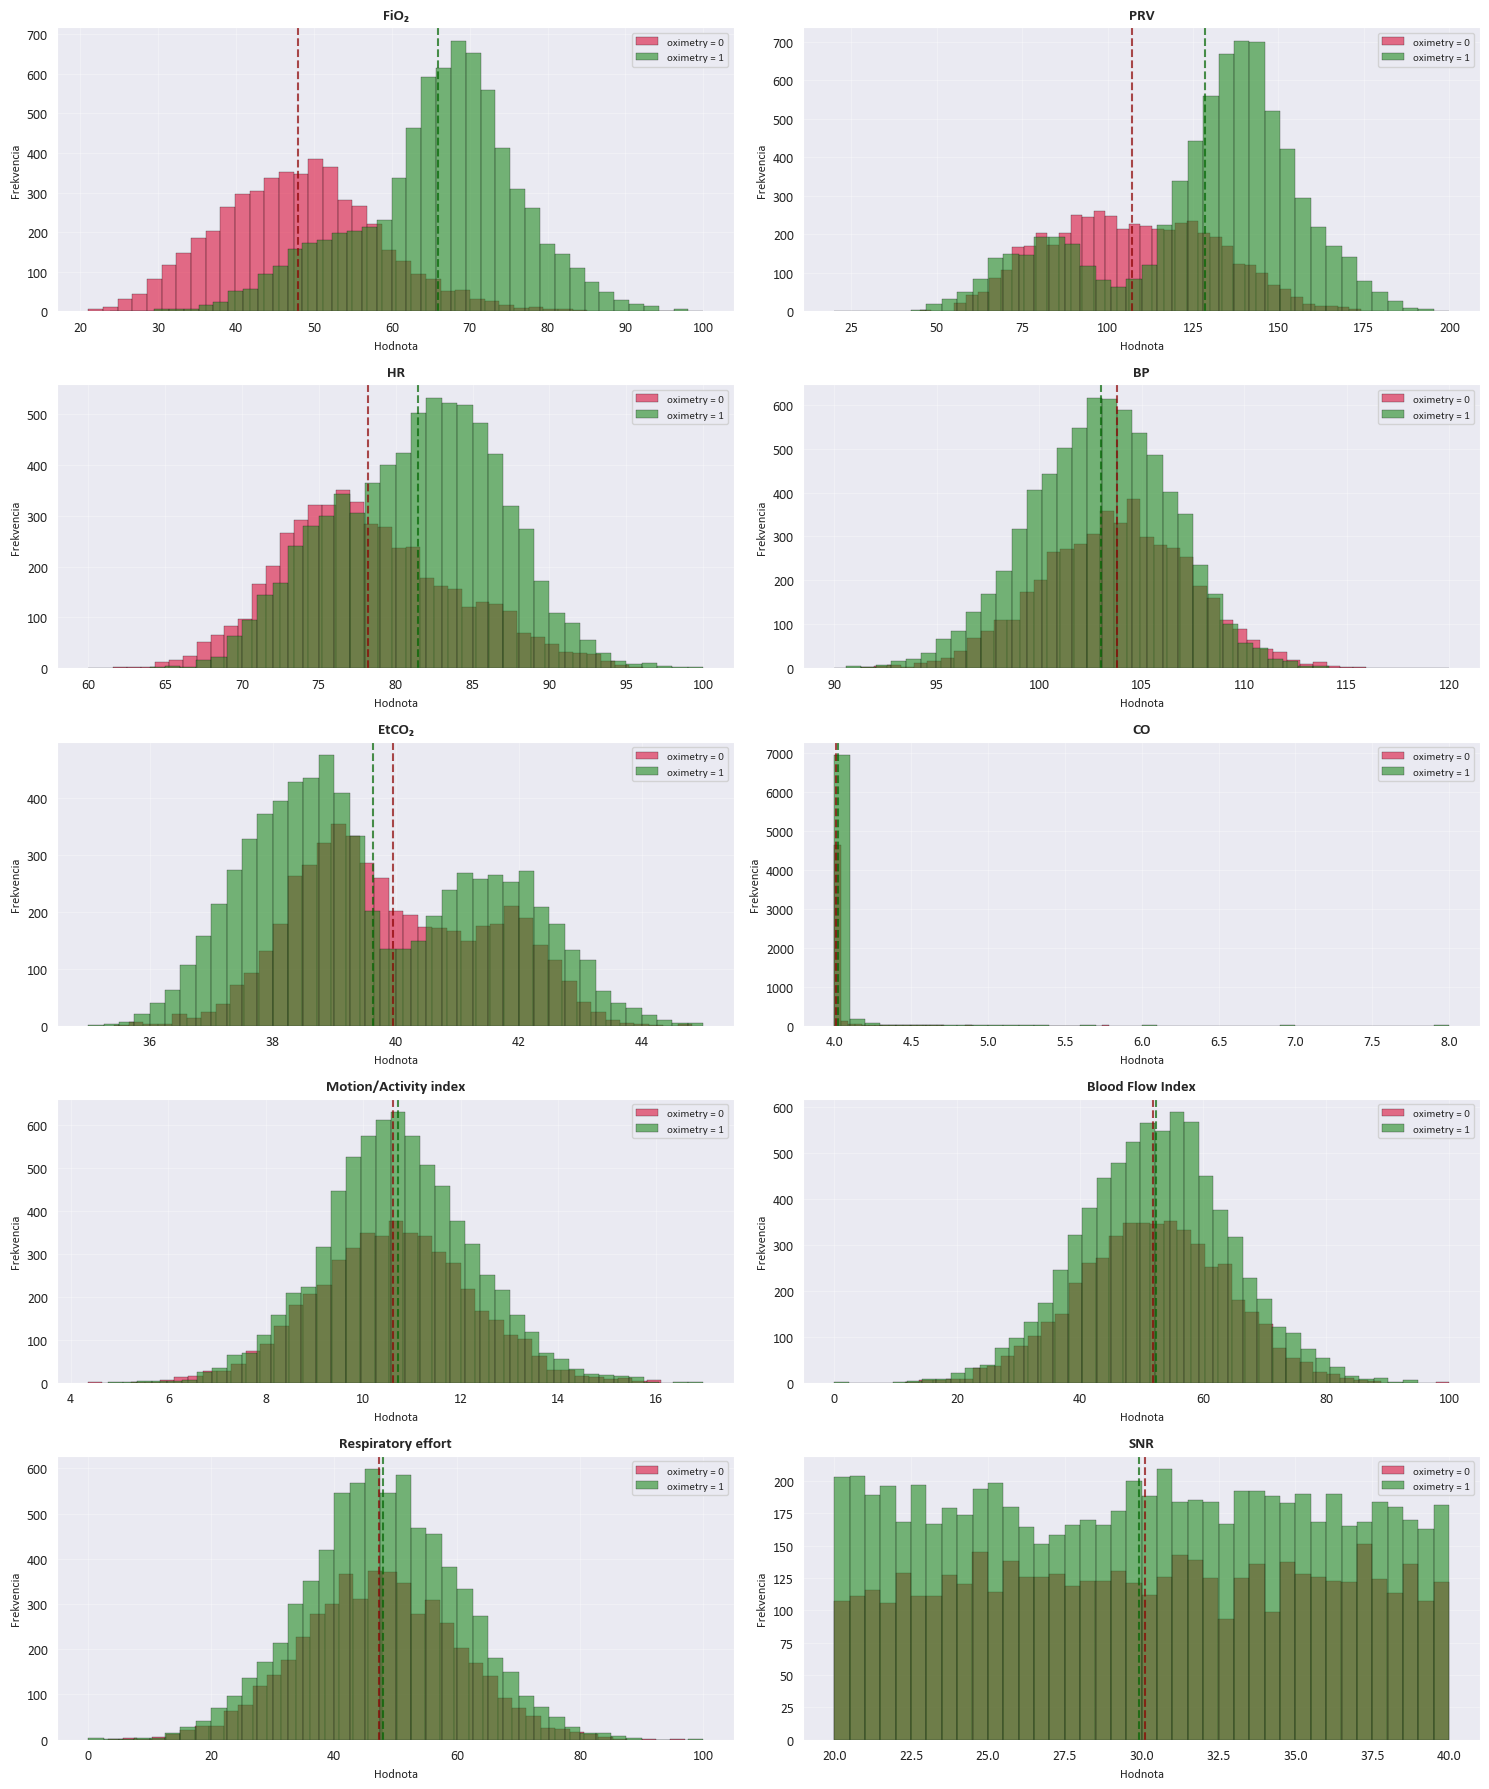

In [399]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, feature in enumerate(key_attributes):
    ox_0 = df_observation[df_observation['oximetry'] == 0][feature].dropna()
    ox_1 = df_observation[df_observation['oximetry'] == 1][feature].dropna()
    
    axes[idx].hist(ox_0, bins=40, alpha=0.6, label='oximetry = 0', color='crimson', edgecolor='black', linewidth=0.3)
    axes[idx].hist(ox_1, bins=40, alpha=0.6, label='oximetry = 1', color='forestgreen', edgecolor='black', linewidth=0.3)
    
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Hodnota', fontsize=9)
    axes[idx].set_ylabel('Frekvencia', fontsize=9)
    axes[idx].legend(fontsize=8, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    
    # Pridanie priemerných hodnôt
    mean_0 = ox_0.mean()
    mean_1 = ox_1.mean()
    axes[idx].axvline(mean_0, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[idx].axvline(mean_1, color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [400]:
t_test_results = []

for feature in key_attributes:
    ox_0 = df_observation[df_observation['oximetry'] == 0][feature].dropna()
    ox_1 = df_observation[df_observation['oximetry'] == 1][feature].dropna()
    
    # T-test
    t_stat, p_value = stats.ttest_ind(ox_0, ox_1)
    
    # Priemerné hodnoty
    mean_0 = ox_0.mean()
    mean_1 = ox_1.mean()
    diff = mean_1 - mean_0
    
    # Signifikancia
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"
    
    t_test_results.append({
        'Atribút': feature,
        'Priemer (ox=0)': mean_0,
        'Priemer (ox=1)': mean_1,
        'Rozdiel': diff,
        't-statistic': t_stat,
        'p-value': p_value,
        'Signifikantný': sig
    })

t_test_df = pd.DataFrame(t_test_results)
t_test_df = t_test_df.sort_values('p-value')

print(t_test_df.to_string(index=False))
print("\nLegenda: *** p<0.001, ** p<0.01, * p<0.05, ns = nesignifikantný\n")

              Atribút  Priemer (ox=0)  Priemer (ox=1)   Rozdiel  t-statistic       p-value Signifikantný
                 FiO₂       47.971581       65.964106 17.992525   -93.763526  0.000000e+00           ***
                  PRV      107.236384      128.540438 21.304055   -43.032547  0.000000e+00           ***
                   HR       78.211095       81.419590  3.208495   -31.152526 4.811471e-205           ***
                   BP      103.790725      103.003807 -0.786918    11.943894  1.064919e-32           ***
                EtCO₂       39.948072       39.638008 -0.310064     9.506483  2.339819e-21           ***
                   CO        4.011926        4.022179  0.010253    -6.676196  2.558960e-11           ***
Motion/Activity index       10.613320       10.704228  0.090908    -3.159587  1.583805e-03            **
     Blood Flow Index       51.780606       52.308132  0.527526    -2.375845  1.752424e-02             *
   Respiratory effort       47.333335       47.881608  

In [401]:
##Finálne zhrnutie párovej analýzy

In [402]:
for _, row in t_test_df.iterrows():
    attr = row['Atribút']
    diff = row['Rozdiel']
    p_val = row['p-value']
    sig = row['Signifikantný']
    
    if sig != "ns":
        if diff > 0:
            interpretacia = f"Pri oximetry=1 je {attr} vyšší o {abs(diff):.3f}"
        else:
            interpretacia = f"Pri oximetry=1 je {attr} nižší o {abs(diff):.3f}"
        
        print(f"{attr}:")
        print(f"  {interpretacia}")
        print(f"  Štatistická významnosť: {sig} (p={p_val:.6f})")
        print()


FiO₂:
  Pri oximetry=1 je FiO₂ vyšší o 17.993
  Štatistická významnosť: *** (p=0.000000)

PRV:
  Pri oximetry=1 je PRV vyšší o 21.304
  Štatistická významnosť: *** (p=0.000000)

HR:
  Pri oximetry=1 je HR vyšší o 3.208
  Štatistická významnosť: *** (p=0.000000)

BP:
  Pri oximetry=1 je BP nižší o 0.787
  Štatistická významnosť: *** (p=0.000000)

EtCO₂:
  Pri oximetry=1 je EtCO₂ nižší o 0.310
  Štatistická významnosť: *** (p=0.000000)

CO:
  Pri oximetry=1 je CO vyšší o 0.010
  Štatistická významnosť: *** (p=0.000000)

Motion/Activity index:
  Pri oximetry=1 je Motion/Activity index vyšší o 0.091
  Štatistická významnosť: ** (p=0.001584)

Blood Flow Index:
  Pri oximetry=1 je Blood Flow Index vyšší o 0.528
  Štatistická významnosť: * (p=0.017524)

Respiratory effort:
  Pri oximetry=1 je Respiratory effort vyšší o 0.548
  Štatistická významnosť: * (p=0.018699)



In [403]:
##Komplexnejšie zamyslenie nad výsledkami - závislosti, hypotézy...
print("""1. ZÁVISLÉ ATRIBÚTY (potenciálne redundantné):
   Identifikovali sme nasledujúce skupiny atribútov s vysokou vzájomnou koreláciou:""")

#nájdeme páry s vysokou koreláciou (>0.7)
high_corr_pairs = corr_df_sorted[
    (corr_df_sorted['Abs. korelácia'] > 0.7) & 
    (corr_df_sorted['Atribút 1'] != 'oximetry') & 
    (corr_df_sorted['Atribút 2'] != 'oximetry')
]

if len(high_corr_pairs) > 0:
    print("\n   Silno korelované páry atribútov:")
    for _, row in high_corr_pairs.iterrows():
        print(f"   - {row['Atribút 1']} ↔ {row['Atribút 2']}: r = {row['Korelácia']:.3f}")
    print("\n  - Tieto atribúty môžu obsahovať redundantnú informáciu")
    print("   - Pri modelovaní zvážiť odstránenie jedného z páru alebo PCA")
else:
    print("\n   - Neboli identifikované silno korelované páry (r > 0.7)")
    print("   - Všetky atribúty prinášajú relatívne nezávislú informáciu")

print("""
2. MOŽNOSTI KOMBINÁCIE ATRIBÚTOV:
   
   a) Fyziologické indexy:
      - Kardiovaskulárny index: kombinác HR, BP, CO
      - Respiračný index: kombinácia RR, EtCO₂, Respiratory effort
      - Perfúzny index: kombinácia Blood Flow Index, PI
   
   b) Feature engineering príležitosti:
      - Pomer FiO₂/SpO₂ → efektivita okysličenia
      - Kombinovaný hemodynamický index
      - Normalizované hodnoty vzhľadom na pohyb pacienta

3. HYPOTÉZY NA TESTOVANIE V ĎALŠÍCH FÁZACH:
   
   H1: FiO₂ má najsilnejší priamy vplyv na oximetry
       - Pacienti s vyšším prívodom kyslíka majú lepšiu saturáciu
   
   H2: Kardiovaskulárne parametre (HR, BP, CO) pôsobia synergicky
       - Kombinácia týchto parametrov lepšie predikuje ako jednotlivé hodnoty
   
   H3: Pohyb pacienta (Motion/Activity index) zavádza šum do meraní
       - Merania pri nižšej aktivite sú spoľahlivejšie
   
   H4: Existujú nelineárne vzťahy medzi prediktormi a target
       - Stromové modely môžu fungovať lepšie ako lineárne

4. IDENTIFIKOVANÉ PROBLÉMY A RIEŠENIA:
   
   Problém 1: Vysoký počet outlierov v CO (13.4%)
   - Riešenie: Odstránenie extrémnych hodnôt
   
   Problém 2: Možná multikolinearita medzi kardiovaskulárnymi parametrami
   - Riešenie: Regularizácia (Ridge/Lasso) alebo PCA
   
   Problém 3: Technické parametre (SNR) ovplyvňujú kvalitu všetkých meraní
   - Riešenie: Filtrovať záznamy s nízkym SNR alebo použiť ako váhu

5. ODPORÚČANIA PRE MODELOVANIE:
   
   a) Príprava dát:
      - Ošetrenie outlierov (najmä v CO)
      - Normalizácia/štandardizácia prediktorov
      - Vytvorenie interakčných termínov pre top prediktory
   
   b) Výber modelu:
      - Začať s lineárnou regresiou ako baseline
      - Testovať nelineárne modely (Random Forest, XGBoost)
      - Zvážiť ensemble metódy
   
   c) Validácia:
      - Cross-validácia na detekciu overfittingu
      - Analýza rezíduí
      - Feature importance analýza

6. INTEGRÁCIA S OSTATNÝMI DATASETMI:
   
   - Dataset PATIENT: demografické faktory (vek, krvná skupina)
     - Môžu ovplyvniť baseline hodnoty fyziologických parametrov
   
   - Dataset STATION: geografická poloha (latitude, longitude)
     - Nadmorská výška môže ovplyvniť baseline saturáciu kyslíka""")

1. ZÁVISLÉ ATRIBÚTY (potenciálne redundantné):
   Identifikovali sme nasledujúce skupiny atribútov s vysokou vzájomnou koreláciou:

   - Neboli identifikované silno korelované páry (r > 0.7)
   - Všetky atribúty prinášajú relatívne nezávislú informáciu

2. MOŽNOSTI KOMBINÁCIE ATRIBÚTOV:

   a) Fyziologické indexy:
      - Kardiovaskulárny index: kombinác HR, BP, CO
      - Respiračný index: kombinácia RR, EtCO₂, Respiratory effort
      - Perfúzny index: kombinácia Blood Flow Index, PI

   b) Feature engineering príležitosti:
      - Pomer FiO₂/SpO₂ → efektivita okysličenia
      - Kombinovaný hemodynamický index
      - Normalizované hodnoty vzhľadom na pohyb pacienta

3. HYPOTÉZY NA TESTOVANIE V ĎALŠÍCH FÁZACH:

   H1: FiO₂ má najsilnejší priamy vplyv na oximetry
       - Pacienti s vyšším prívodom kyslíka majú lepšiu saturáciu

   H2: Kardiovaskulárne parametre (HR, BP, CO) pôsobia synergicky
       - Kombinácia týchto parametrov lepšie predikuje ako jednotlivé hodnoty

   H3: Pohyb